# CIBUSmod impact analysis notebook
This notebook provides example functions and illustrations of how the data generated within the `run_scn` notebook can be selected and visualised 

In [1]:
import sys
import os

import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(),'..'))
import CIBUSmod as cm
import CIBUSmod.temp_calc.temp_utils as temp_utils

# Initialize the modules used to plot and analyze data
#import pandas as pd

## Initialize a `SoilDataExplore` scenario instances.
 The scenario instance get automatically populated with the datasets generated using the SoilData class.

In [ ]:
FAI = cm.SoilDataExplore('FAI', verbose=False)
FAC = cm.SoilDataExplore('FAC', verbose=False)
FAI_no_cows = cm.SoilDataExplore('FAI_no_cows', verbose=False)

# To analyze temperature response and total SOC series of several scenarios, initialize a ScenarioTempCalc instance

In [2]:
# Recreate a saved instance.
# Execute:
ScnCompare = cm.ScenarioTempCalc.load_instance_state('ScnCompare')
ScnCompare.load_inventory()

---Loading saved instance state---
+++Instance state loaded+++
---Loading datasets---
---Loading datasets---
The following dataset variables have been set:
 timeseries_Sweden
+++Datasets loaded+++
---Loading datasets---
The following dataset variables have been set:
 timeseries_regions
+++Datasets loaded+++
---Loading datasets---
The following dataset variables have been set:
 timeseries_Sweden_prod_system
+++Datasets loaded+++
---Loading datasets---
The following dataset variables have been set:
 timeseries_regions_prod_system
+++Datasets loaded+++
No dataset variables have been loaded.
+++Datasets loaded+++


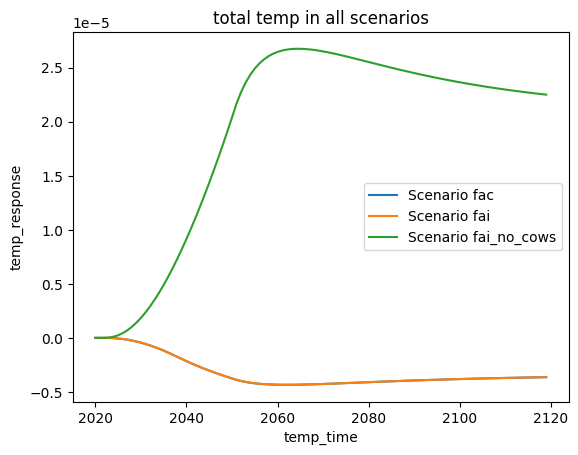

In [6]:
ScnCompare.plot_series_Sweden(ScnCompare.timeseries_Sweden, type='temp', yr_range=[2020,2050], save_as='ScnCompare')  

In [7]:
ScnCompare.check_attributes_status()

('The following attributes are set for public variables',
 {'datasets': ('list', True),
  'scenarios': ('list', True),
  'timeseries_Sweden': ('Dataset', True),
  'timeseries_Sweden_prod_system': ('Dataset', True),
  'timeseries_dataset': ('Dataset', True),
  'timeseries_regions': ('Dataset', True),
  'timeseries_regions_prod_system': ('Dataset', True)})

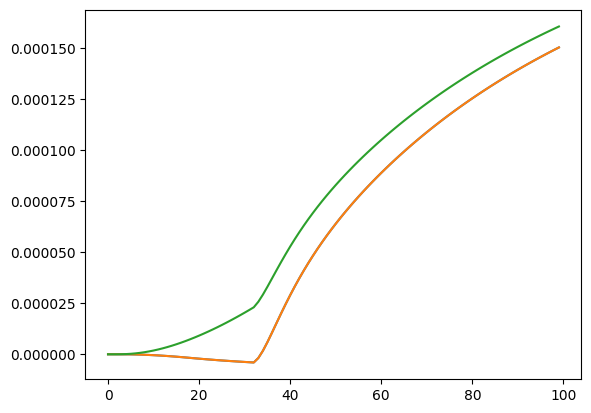

In [52]:
il.reload(CIBUSmod.temp_calc.temp_utils)
#new_set = temp_utils.add_temp_response(ScnCompare.timeseries_Sweden)
#ScnCompare.timeseries_Sweden
for i in new_set.temp_response.sum('output_year'):
    plt.plot(i)

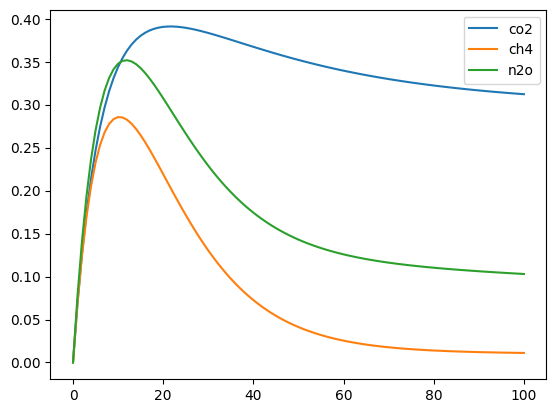

In [29]:
import importlib as il
import matplotlib.pyplot as plt
import CIBUSmod.temp_calc.temp_utils
il.reload(CIBUSmod.temp_calc.temp_utils)
co2 = temp_utils.ghg_to_temp('co2', re_basis='vol')
ch4 = temp_utils.ghg_to_temp('ch4', re_basis='vol')
n2o = temp_utils.ghg_to_temp('n2o', re_basis='vol')

plt.plot(co2, label='co2')
plt.plot(ch4, label='ch4')
plt.plot(n2o, label='n2o')
plt.legend()

In [3]:
# Or, if no saved instance exists.
# Create a new instance
ScnCompare = cm.ScenarioTempCalc(FAI.total_soc_inventory, FAI_no_cows.total_soc_inventory, FAC.total_soc_inventory)

Starting temp calc
Starting stacking operation
Starting temp_calc inner loop
Done with temp_calc inner loop
Dataset created. <xarray.Dataset> Size: 52MB
Dimensions:        (region: 106, output_year: 100, prod_system: 2, scn: 3,
                    temp_time: 100)
Coordinates:
  * region         (region) int32 424B 111 112 311 312 ... 2511 2512 2519 2521
  * output_year    (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
  * prod_system    (prod_system) object 16B 'conventional' 'organic'
  * scn            (scn) object 24B 'fac' 'fai' 'fai_no_cows'
  * temp_time      (temp_time) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
Data variables:
    co2_flux       (scn, prod_system, region, output_year) float64 509kB 0.0 ...
    tot_soc        (scn, prod_system, region, output_year) float64 509kB 1.09...
    temp_response  (region, output_year, prod_system, scn, temp_time) float64 51MB ...
dataset returned by function


In [22]:
# To save the current state of the instance, for continuing reloading in a new session.
# Execute
ScnCompare.save_instance_state('ScnCompare')
ScnCompare.save_inventory()

---Saving current instance state---
+++Saved instance variable states to C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\data\soil\temp_results/ScnCompare.pickle+++
Dataset set to ['timeseries_Sweden', 'timeseries_regions', 'timeseries_Sweden_prod_system', 'timeseries_regions_prod_system']
---Saving datasets---
timeseries_Sweden saved as timeseries_Sweden.nc in C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\data\soil\temp_results
+++Datsets saved+++
---Saving datasets---
timeseries_regions saved as timeseries_regions.nc in C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\data\soil\temp_results
+++Datsets saved+++
---Saving datasets---
timeseries_Sweden_prod_system saved as timeseries_Sweden_prod_system.nc in C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\data\soil\temp_results
+++Datsets saved+++
---Saving datasets---
timeseries_regions_prod_system saved as timeseries_regions_prod_system.nc in C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\data\soil\temp_results
+++Datsets 

In [9]:
NewCompare = cm.ScenarioTempCalc.load_instance_state('ScnCompare')
NewCompare.load_inventory()

AttributeError: 'ScenarioTempCalc' object has no attribute '_print_loaded_items'

In [17]:
test = ScnCompare.timeseries_Sweden.temp_response.sum('output_year')
new_Series = temp_utils.add_temp_response(ScnCompare.timeseries_Sweden, vers='old')

Starting temp calc
Starting stacking operation
Starting temp_calc inner loop


OutOfBoundsDatetime: Out of bounds timestamp: 2263-01-01 00:00:00 with frequency 'ns'

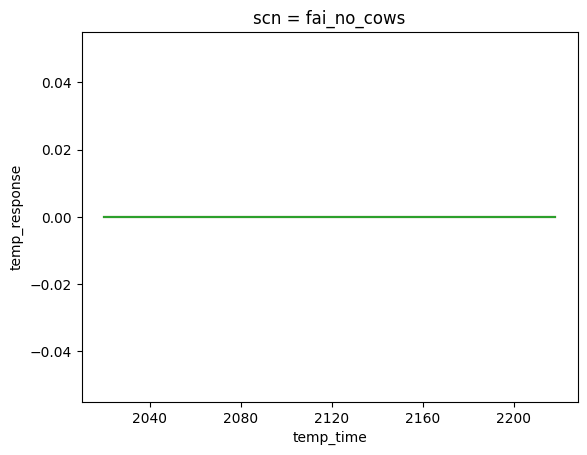

In [14]:
for i in test:
    i.plot()

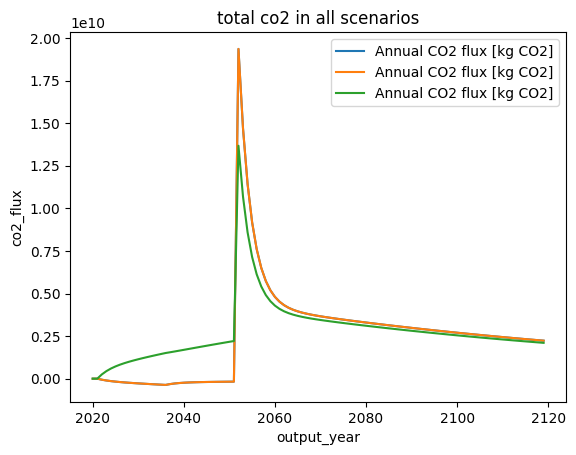

In [4]:
#ScnCompare.plot_series_Sweden(ScnCompare.co2_flux_Sweden)
ScnCompare.plot_series_Sweden(ScnCompare.co2_flux_Sweden, type='co2')

In [7]:
temp_utils.add_temp_response(ScnCompare.co2_flux_Sweden)

Starting temp calc
Starting stacking operation
Starting temp_calc inner loop
Done with temp_calc inner loop
Dataset created. <xarray.Dataset> Size: 482kB
Dimensions:        (output_year: 100, scn: 3, temp_time: 199)
Coordinates:
  * output_year    (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
  * scn            (scn) object 24B 'fac' 'fai' 'fai_no_cows'
  * temp_time      (temp_time) datetime64[ns] 2kB 2020-01-01 ... 2218-01-01
Data variables:
    co2_flux       (scn, output_year) float64 2kB 0.0 -1.958e+05 ... 2.104e+09
    temp_response  (output_year, scn, temp_time) float64 478kB nan nan ... nan
dataset returned by function


<xarray.Dataset> Size: 482kB
Dimensions:        (output_year: 100, scn: 3, temp_time: 199)
Coordinates:
  * output_year    (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
  * scn            (scn) object 24B 'fac' 'fai' 'fai_no_cows'
  * temp_time      (temp_time) datetime64[ns] 2kB 2020-01-01 ... 2218-01-01
Data variables:
    co2_flux       (scn, output_year) float64 2kB 0.0 -1.958e+05 ... 2.104e+09
    temp_response  (output_year, scn, temp_time) float64 478kB nan nan ... nan

In [9]:
ScnCompare.plot_series_Sweden(ScnCompare.co2_flux_Sweden, type='temp')

AttributeError: 'Dataset' object has no attribute 'temp_response'

3

# To generate an interactive map with regions in Sweden that can be used to identify codes used in the inventory datasets, uncomment (remove #) and run the following cell

In [ ]:
#FAI.plot_regions('sko')

# Set the years for which SOC stocks should be compared in the subsequent calls
Set the years in the following cell to use the same initial and final year in all plots
Some og the plots can be generated with both the 'conventional' and 'organic' systems included (2x2 plot) setting system='both', or for either system separately (as a 2x1 plot) specifying the name of the system ('organic' or 'conventional'). 

In [ ]:
initial = '2020' # use strings to avoid timeseries interpretation issues
final = '2050' # use strings to avoid timeseries interpretation issues
# TODO: Add checks and corrective actions for parameters taking year as input to all methods

# Plot the SOC level and changes between two arbitrary years with and a number of available combinations 
(See comments behind input variables below) 

In [ ]:
agr_system = 'organic' # 'all', 'conventional, 'organic'
startyear = '2030' # <inital> can be passed here  
finalyear = '2040' # <final> can be passed here
change_type = 'initial' # 'total_change', 'initial', 'final', 'percentage_change'
region_type = 'ha' # 'region', 'ha', 'area' ('area' can not be used with '_SOC')
soc_switch = '_SOC' # '_SOC', '' ('_SOC' can not be used with 'area', '_SOC' must be used with 'ha' and 'region)
dataset = f'{change_type}{soc_switch}_{region_type}'
out = FAI_no_cows.plot_soc_map(system=agr_system, plot_set=dataset, colormap='Spectral', title=f"{change_type}{soc_switch} per {region_type} unit.\n{agr_system} agriculture in Sweden\n initial year: {startyear}\nfinal year: {finalyear}\n{FAI_no_cows.name}", save_as=f"{change_type}{soc_switch}_per_{region_type}_({agr_system} agriculture_initial year-{startyear}_final year-{finalyear}")

# Compare percentual SOC stock change and cumulative CO2 emissions between two years for all regions

In [ ]:
# To see all options uncomment and run line below
#FAI.plot_soc_co2_regions_map?
# Set the following variable to select whether to plot 'conventional' or 'organic' systems
agr_type = 'all' # 'organic' or 'conventional' or 'all'
save_text = f"SOC_CO2_all_regions_map_{initial}_{final}(ha_{agr_type})"
output = FAI_no_cows.plot_soc_co2_regions_map(initial_year=initial, final_year=final, save_as=save_text, system=agr_type, colormaps=['Spectral_r', 'RdBu', 'Spectral', 'Spectral'], width=10, height_scaling=1.3, standard_font=9, verbose=False, mask_outlier=True, mask_subplots=[1,2,4])

# Plot the SOC stocks in all regions for two separate years

In [ ]:
# Figure will be saved to '<save_as>.svg' and '<save_as>.png' in the data/soil/exported_results folder
# To see all options uncomment and run line below
#FAI.plot_soc_stock_maps?
# hint: colormap can be changed using the 'colormap' keyword. Some examples: 'YlOrBr_r'(default) 'YlGnBu'
## Available color maps 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

## uncomment to save output to figures
#FAI.plot_soc_stock_maps(system='both', colormap='Spectral', initial_year=initial, final_year=final,save_as=f'SOC_stocks_map_{initial}_{final}(ha)_both_systems', width=10, height_scaling=0.8, verbose=False)
## uncomment to NOT save output to figures
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic maps
FAI_no_cows.plot_soc_stock_maps(system='both', colormap='Spectral', initial_year=initial, final_year=final, width=10, height_scaling=0.8, verbose=False)
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic horisontal bars
#FAI.plot_soc_stock_maps(system='both', initial_year=initial, final_year=final, width=10, height_scaling=1.75, verbose=False, kind='barh', xlabel='SOC in top soil [kg]')
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic boxplot
#FAI.plot_soc_stock_maps(system='both', initial_year=initial, final_year=final, width=12, height_scaling=0.3, verbose=False, kind='box', ylabel='SOC in top soil [kg]')
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic histogram
#FAI.plot_soc_stock_maps(system='both', initial_year=initial, final_year=final, width=10, height_scaling=0.6, verbose=False, kind='hist', bins=40, xlabel='SOC in top soil [kg]')

## To detect outliers the 'outlier_detect' method can be used
A dataseries can be plotted either as a boxplot (default), or as a scatter plot, using a second series with the same coordinates for the y-axis. A Z-score test with summary statirstics can also be used to automatically detect outliers, based on a provided threshold key-argument. Default value is 3. 

Outliers automatically identified while running plots are also stored in an instance variable as a dict. 

In [ ]:
FAI.outlier_detect?
for i in FAI.outliers.keys():
    print(i)

# Create a single subplot with percentage change between two years for all regions

In [ ]:
# Set the following variable to select whether to plot 'conventional' or 'organic' systems
agr_type = 'organic' # 'organic' or 'conventional'
stock_ser = FAI_no_cows.plot_all_regions_map(colormap='RdBu_r', initial_year=initial, final_year=final, system=agr_type, save_as=f'SOC_change_{initial}_{final}', width=7, title=f'SOC stock changes {initial}-{final} (per ha)\n{agr_type} agriculture\n{FAI_no_cows.name}', legend_kwds={'label': 'Percentage change, top soil (%)'})

# Plot the SOC time series for historic input, new input and total input (historic + new) for a single sko

In [ ]:
# To switch between results/ha and results/region(sko) use '_ha' or '_kgc' (adjust if input_df changes the use of suffix)
reg = 312
system = 'conventional'
sel1 = '_ha'
sel2 = 'crop_ha'
all_soc_fractions = FAI_no_cows.plot_single_region_timeseries(sko=312, system='conventional', selection=sel1, save_as=f'Total_SOC_time_series_(sko-{reg}_system-{system}_selection-{sel2})', min_year=2020, max_year=2050)
crop_soc_fractions = FAI_no_cows.plot_single_region_timeseries(sko=312, system='conventional', selection=sel2, save_as=f'crop_SOC_time_series_(sko-{reg}_system-{system}_selection-{sel2})', min_year=2020, max_year=2050)

# Plot and compare single fraction to the total SOC of a region
The `fraction` keyword must end exactly as the fraction that should be
To see available fractions run
list(FAI.total_soc_inventory['fraction'].values)

In [ ]:
frac = 'crop_ha'
reg = 312
system = 'conventional'
output = FAI_no_cows.plot_fraction_total_timeseries_comparison(sko=reg, system=system, selection='_ha', fraction=frac, fraction_name='Crops', min_year=2020, max_year=2050, save_as=f'comparison_total_vs_{frac}_timeseries_(sko-{reg}_system-{system})')

# Plot SOC stocks in initial and final years for different fractions, both conv. and org.

In [ ]:
selection = FAI.show_variable_values()
sko = [item for item in selection if '_kgc' in item]
ha = [item for item in selection if '_ha' in item]
ha_manure = [item for item in ha if 'manure' in item]
ha_crop = [item for item in ha if 'crop' in item]
sko_manure = [item for item in sko if 'manure' in item]
sko_crop = [item for item in sko if 'crop' in item]

In [ ]:
# set the plot_sel to any of the above variables
plot_sel = ha_crop
for i in plot_sel:
    FAI_no_cows.plot_soc_stock_maps(system='both', colormap='RdBu_r', vers=i, initial_year=initial, final_year=final, width=10, height_scaling=0.8, verbose=False)

# Investigate the dataset interactively

In [ ]:
FAI.total_soc_inventory

# To explore return values, work below this heading - to avoid messing up the notebook structure

In [ ]:
FAI.check_attributes_status()

In [ ]:
FAI.outliers.keys()

In [ ]:
AI_no_cows.total_soc_inventory

In [ ]:
# Create a dataset with the co2_flux timeseries in all scenarios
All_co2_inventory = xr.merge([FAI.total_soc_inventory.co2_flux, FAC.total_soc_inventory.co2_flux, FAI_no_cows.total_soc_inventory.co2_flux])

In [ ]:
# Create a dataset with the total soc timeseries in all scenarios
All_soc_inventory = xr.merge([FAI.total_soc_inventory.tot_soc, FAC.total_soc_inventory.tot_soc, FAI_no_cows.total_soc_inventory.tot_soc])

In [ ]:
All_soc_inventory

In [ ]:
# Total co2 fluxes - Sweden
co2_flux_Sweden = All_co2_inventory.sum(['input_year', 'fraction', 'prod_system', 'region'])
co2_flux_Sweden_prod_system = All_co2_inventory.sum(['input_year', 'fraction', 'region'])
# Total co2 fluxes - regions
co2_flux_regions = All_co2_inventory.sum(['input_year', 'fraction', 'prod_system'])
co2_flux_regions_prod_system = All_co2_inventory.sum(['input_year', 'fraction'])

In [ ]:
# Total soc level - Sweden
tot_soc_Sweden = All_soc_inventory.sum(['input_year', 'fraction', 'prod_system', 'region'])
tot_soc_Sweden_prod_system = All_soc_inventory.sum(['input_year', 'fraction', 'region'])
# Total soc levels - regions
tot_soc_regions = All_soc_inventory.sum(['input_year', 'fraction', 'prod_system'])
tot_soc_regions_prod_system = All_soc_inventory.sum(['input_year', 'fraction'])

In [ ]:
# Single scenario dataarrays - co2_flux
fai_co2 = co2_flux_Sweden.sel(scn='fai')
fai_nc_co2 = co2_flux_Sweden.sel(scn='fai_no_cows')
fac_co2 = co2_flux_Sweden.sel(scn='fac')
# Single scenario dataarrays - tot_soc
fai_soc = tot_soc_Sweden.sel(scn='fai')
fai_nc_soc = tot_soc_Sweden.sel(scn='fai_no_cows')
fac_soc = tot_soc_Sweden.sel(scn='fac')

In [ ]:
#plot the co2 fluxes
fai_co2['co2_flux'].plot(label='FAI')
fai_nc_co2['co2_flux'].plot(label='FAI no cows')
fac_co2['co2_flux'].plot(label='FAC')
plt.title('Time Series Plot')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#plot the soc levels

fai_nc_soc['tot_soc'].plot(label='FAI no cows')
fac_soc['tot_soc'].plot(label='FAC')
fai_soc['tot_soc'].plot(label='FAI')
plt.title('Time Series Plot')
plt.legend()
plt.grid(True)
plt.xlim(pd.to_datetime('2019'), pd.to_datetime('2050'))

plt.show()

In [ ]:
tot_co2_flux_Sweden